In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.tools import diff
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')
plt.rc("figure", figsize=(16, 5))

### Forecasting time series data using auto_arima

In [2]:
import pmdarima as pm

In [3]:
path = Path('../../../Code in Zip/Time-Series-Analysis-with-Python-Cookbook-main/datasets/Ch11')

milk = pd.read_csv(path / 'milk_production.csv', index_col='month', parse_dates=True)

milk.head()

,production
month,
1962-01-01,589
1962-02-01,561
1962-03-01,640
1962-04-01,656
1962-05-01,727


In [4]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(milk, test_size=.10, shuffle=False)

train, test = pm.model_selection.train_test_split(milk, test_size=.10)

print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (151, 1)
Test: (17, 1)


You will use the auto_arima function from pmdarima to optimize and find the best configuration for your SARIMA model. Prior knowledge about the milk data is key to obtaining the best results from auto_arima. You know the data has a seasonal pattern, so you will need to provide values for the two parameters: seasonal=True and m=12 (the number of periods in a season). If these values are not set, the model will only search for the non-seasonal orders (p, d, q).

In [5]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', stepwise=True)

auto_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 16 Jan 2025   AIC                            956.016
Time:                                    23:11:37   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [6]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', stepwise=True, trace=True)

auto_model.summary()

Performing stepwise search to minimize aic


 ARIMA(2,1,2)(1,1,1)[12]             : AIC=961.878, Time=3.21 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1005.341, Time=0.07 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=971.814, Time=0.48 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=956.016, Time=0.40 sec
 ARIMA(0,1,1)(0,1,0)[12]             : AIC=996.508, Time=0.09 sec
 ARIMA(0,1,1)(1,1,1)[12]             : AIC=957.982, Time=1.66 sec
 ARIMA(0,1,1)(0,1,2)[12]             : AIC=957.967, Time=1.20 sec
 ARIMA(0,1,1)(1,1,0)[12]             : AIC=971.938, Time=0.30 sec
 ARIMA(0,1,1)(1,1,2)[12]             : AIC=960.016, Time=2.04 sec
 ARIMA(0,1,0)(0,1,1)[12]             : AIC=964.474, Time=0.21 sec
 ARIMA(1,1,1)(0,1,1)[12]             : AIC=957.884, Time=0.70 sec
 ARIMA(0,1,2)(0,1,1)[12]             : AIC=957.783, Time=1.32 sec
 ARIMA(1,1,0)(0,1,1)[12]             : AIC=956.436, Time=1.00 sec
 ARIMA(1,1,2)(0,1,1)[12]             : AIC=959.701, Time=2.05 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=958.000, Time=0.96 sec

Best mod

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 16 Jan 2025   AIC                            956.016
Time:                                    23:11:53   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [7]:
auto_model = pm.auto_arima(train, seasonal=True, m=12, test='adf', 
                           information_criterion='bic', stepwise=True,
                           trace=True)

auto_model.summary()

Performing stepwise search to minimize bic
 ARIMA(2,1,2)(1,1,1)[12]             : BIC=982.369, Time=2.50 sec
 ARIMA(0,1,0)(0,1,0)[12]             : BIC=1008.269, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : BIC=980.596, Time=0.27 sec
 ARIMA(0,1,1)(0,1,1)[12]             : BIC=964.798, Time=0.77 sec
 ARIMA(0,1,1)(0,1,0)[12]             : BIC=1002.362, Time=0.12 sec
 ARIMA(0,1,1)(1,1,1)[12]             : BIC=969.691, Time=1.49 sec
 ARIMA(0,1,1)(0,1,2)[12]             : BIC=969.676, Time=1.08 sec
 ARIMA(0,1,1)(1,1,0)[12]             : BIC=980.720, Time=1.17 sec
 ARIMA(0,1,1)(1,1,2)[12]             : BIC=974.652, Time=1.96 sec
 ARIMA(0,1,0)(0,1,1)[12]             : BIC=970.329, Time=0.56 sec
 ARIMA(1,1,1)(0,1,1)[12]             : BIC=969.593, Time=1.20 sec
 ARIMA(0,1,2)(0,1,1)[12]             : BIC=969.493, Time=0.60 sec
 ARIMA(1,1,0)(0,1,1)[12]             : BIC=965.218, Time=0.37 sec
 ARIMA(1,1,2)(0,1,1)[12]             : BIC=974.337, Time=0.89 sec
 ARIMA(0,1,1)(0,1,1)[12] interc

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -475.008
Date:                            Thu, 16 Jan 2025   AIC                            956.016
Time:                                    23:12:07   BIC                            964.798
Sample:                                01-01-1962   HQIC                           959.585
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1         -0.2714      0.082     -3.326      0.001      -0.431      -0.111
ma.S.L12      -0.6233      0.079     -7.908      0.000      -0.778      -0.469
sigma2        54.7638      5.498      9.960      0.000      43.987      65.540
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                31.78
Prob(Q):                              0.92   Prob(JB):                         0.00
Heteroskedasticity (H):               1.22   Skew:                             0.74
Prob(H) (two-sided):                  0.50   Kurtosis:                         4.83
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

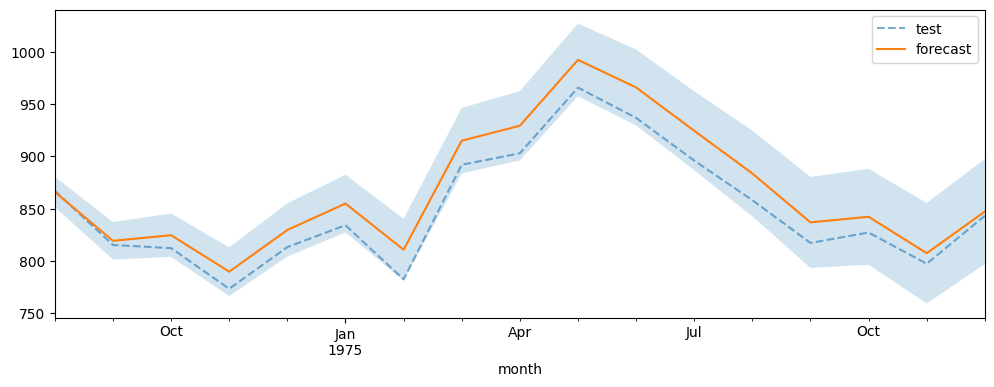

In [8]:
n = test.shape[0]
forecast, conf_interval = auto_model.predict(n_periods=n, return_conf_int=True)
lower_ci, upper_ci = zip(*conf_interval)

index = test.index
ax = test.plot(style='--', alpha=0.6, figsize=(12,4))
pd.Series(forecast, index=index).plot(style='-', ax=ax)
plt.fill_between(index, lower_ci, upper_ci, alpha=0.2)
plt.legend(['test','forecast']); plt.show()

In [9]:
sum(forecast) == sum(conf_interval.mean(axis=1))

True

In [10]:
from pmdarima.arima.utils import ndiffs, nsdiffs


n_adf = ndiffs(milk, test='adf')
# KPSS test (the default in auto_arima):
n_kpss = ndiffs(milk, test='kpss')
n_pp = ndiffs(milk, test='pp')
n_ch = nsdiffs(milk, test='ocsb', m=10, max_D=12,)
n_ocsb = nsdiffs(milk, test='ch' , m=10, max_D=12,)

In [11]:
model = pm.auto_arima(
    train,
    seasonal=True,
    with_intercept=True,
    d=1,
    max_d=2,
    start_p=0, max_p=2,
    start_q=0, max_q=2,
    m=12,
    D=1,
    max_D=2,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    information_criterion='aic',
    stepwise=False,
    out_of_sample_siz=25,
    test = 'kpss',
    score='mape',
    trace=True
)

 ARIMA(0,1,0)(0,1,0)[12] intercept   : AIC=1007.319, Time=0.04 sec
 ARIMA(0,1,0)(0,1,1)[12] intercept   : AIC=966.470, Time=0.71 sec
 ARIMA(0,1,0)(0,1,2)[12] intercept   : AIC=968.422, Time=0.87 sec
 ARIMA(0,1,0)(1,1,0)[12] intercept   : AIC=983.036, Time=0.43 sec
 ARIMA(0,1,0)(1,1,1)[12] intercept   : AIC=968.438, Time=0.34 sec
 ARIMA(0,1,0)(1,1,2)[12] intercept   : AIC=970.470, Time=1.02 sec
 ARIMA(0,1,0)(2,1,0)[12] intercept   : AIC=973.451, Time=0.74 sec
 ARIMA(0,1,0)(2,1,1)[12] intercept   : AIC=968.640, Time=1.08 sec
 ARIMA(0,1,0)(2,1,2)[12] intercept   : AIC=inf, Time=6.04 sec
 ARIMA(0,1,1)(0,1,0)[12] intercept   : AIC=998.468, Time=0.13 sec
 ARIMA(0,1,1)(0,1,1)[12] intercept   : AIC=958.000, Time=0.52 sec
 ARIMA(0,1,1)(0,1,2)[12] intercept   : AIC=959.947, Time=1.04 sec
 ARIMA(0,1,1)(1,1,0)[12] intercept   : AIC=973.934, Time=0.62 sec
 ARIMA(0,1,1)(1,1,1)[12] intercept   : AIC=959.963, Time=1.81 sec
 ARIMA(0,1,1)(1,1,2)[12] intercept   : AIC=962.000, Time=2.40 sec
 ARIMA(0,1,1)

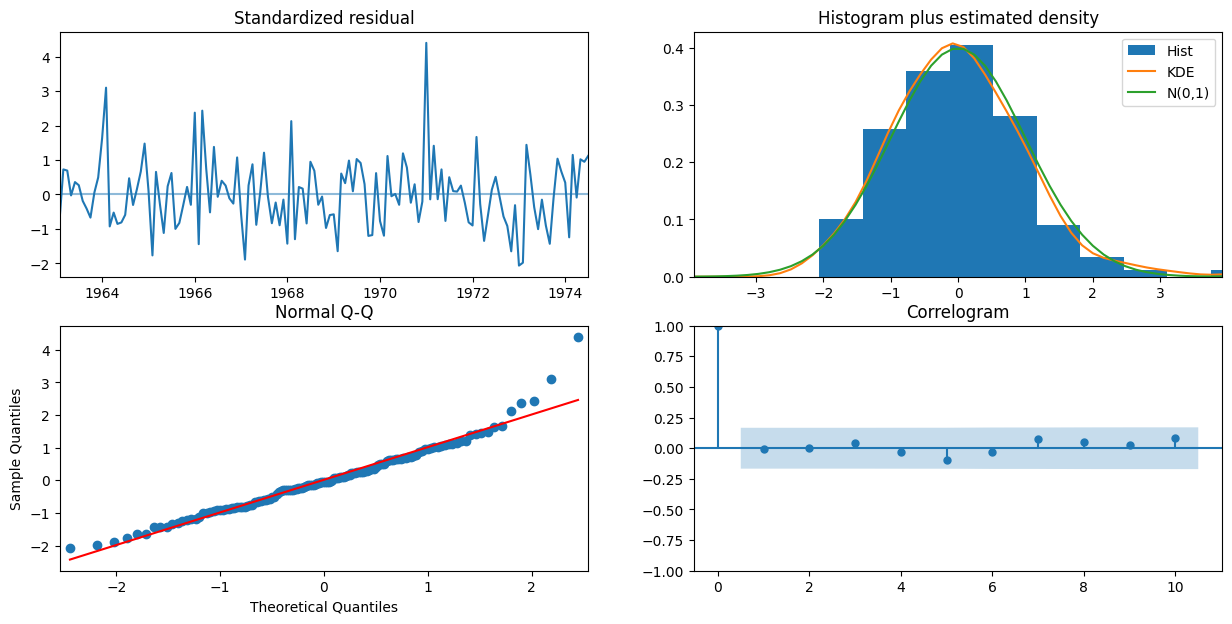

In [12]:
model.plot_diagnostics(figsize=(15,7)); plt.show()

In [13]:
model.out_of_sample_size

0

In [14]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                     SARIMAX Results                                      
==========================================================================================
Dep. Variable:                                  y   No. Observations:                  151
Model:             SARIMAX(2, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -472.969
Date:                            Thu, 16 Jan 2025   AIC                            957.937
Time:                                    23:14:56   BIC                            975.501
Sample:                                01-01-1962   HQIC                           965.075
                                     - 07-01-1974                                         
Covariance Type:                              opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0460      0.621     -0.074      0.941      -1.263       1.171
ar.L1         -1.1997      0.092    -13.044      0.000      -1.380      -1.019
ar.L2         -0.3072      0.098     -3.137      0.002      -0.499      -0.115
ma.L1          0.9585      0.066     14.616      0.000       0.830       1.087
ma.S.L12      -0.6124      0.084     -7.289      0.000      -0.777      -0.448
sigma2        52.8038      5.479      9.637      0.000      42.065      63.543
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                41.88
Prob(Q):                              0.96   Prob(JB):                         0.00
Heteroskedasticity (H):               1.28   Skew:                             0.82
Prob(H) (two-sided):                  0.41   Kurtosis:                         5.14
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### Forecasting time series data using Facebook Prophet

The Prophet algorithm is an additive regression model that can handle non-linear trends
and works well with strong seasonal effects. The algorithm decomposes a time series into
three main components: trend, seasonality, and holidays. The model can be written
as follows:

            y(𝑡) = g(𝑡) + s(𝑡) + h(𝑡) + ϵ𝑡

Here, g(𝑡) is the trend function, s(𝑡) represents the periodic seasonality function, h(𝑡) covers effects of holidays, and ϵ𝑡 is the error term (residual).

The algorithm uses Bayesian inferencing to automate many aspects of tuning the model and finding the optimized values for each component. Behind the scenes, Prophet uses **Stan**, a library for Bayesian inferencing, through the **PyStan** library as the Python
interface to Stan.

In [15]:
from prophet import Prophet

milk = pd.read_csv(path / 'milk_production.csv', parse_dates=['month'])

milk.columns = ['ds','y']
milk.tail()

,ds,y
163,1975-08-01,858
164,1975-09-01,817
165,1975-10-01,827
166,1975-11-01,797
167,1975-12-01,843


In [16]:
# Split the data
idx = round(len(milk) * 0.90)
train = milk[:idx]
test = milk[idx:]
print(f'Train: {train.shape}')
print(f'Test: {test.shape}')

Train: (151, 2)
Test: (17, 2)


<Axes: title={'center': 'Monthly milk production'}, xlabel='ds'>

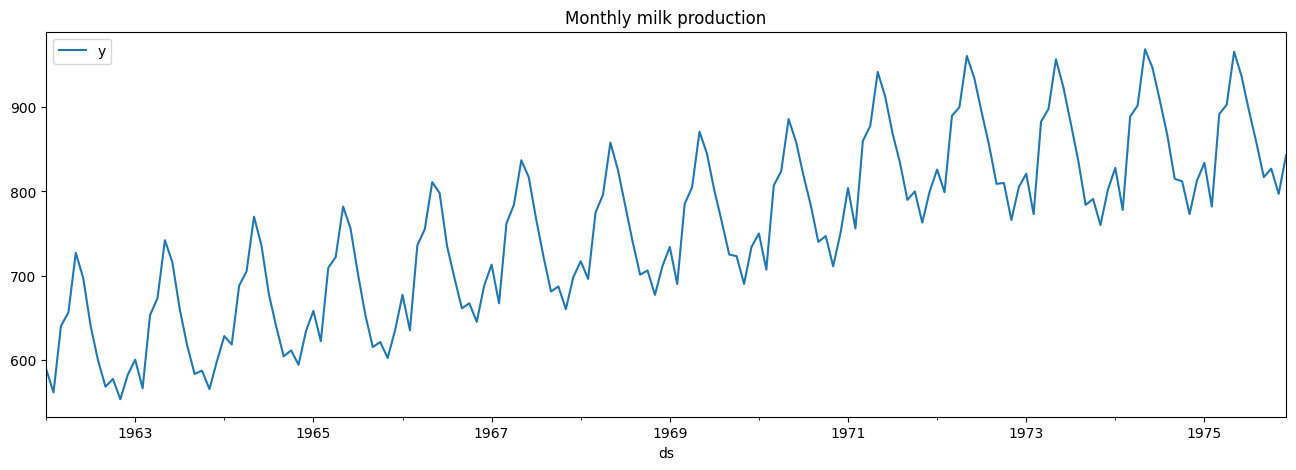

In [17]:
milk.set_index('ds').plot(title="Monthly milk production")

In [18]:
model = Prophet().fit(train)

23:15:06 - cmdstanpy - INFO - Chain [1] start processing
23:15:07 - cmdstanpy - INFO - Chain [1] done processing


In [19]:
model.seasonalities

OrderedDict([('yearly',
              {'period': 365.25,
               'fourier_order': 10,
               'prior_scale': 10.0,
               'mode': 'additive',
               'condition_name': None})])

In [20]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [21]:
future = model.make_future_dataframe(len(test), freq='MS')

In [22]:
len(milk) == len(future)

True

In [23]:
forecast = model.predict(future)
forecast.columns

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'yearly', 'yearly_lower', 'yearly_upper', 'multiplicative_terms',
       'multiplicative_terms_lower', 'multiplicative_terms_upper', 'yhat'],
      dtype='object')

In [24]:
cols = ['ds', 'yhat', 'yhat_lower', 'yhat_upper']

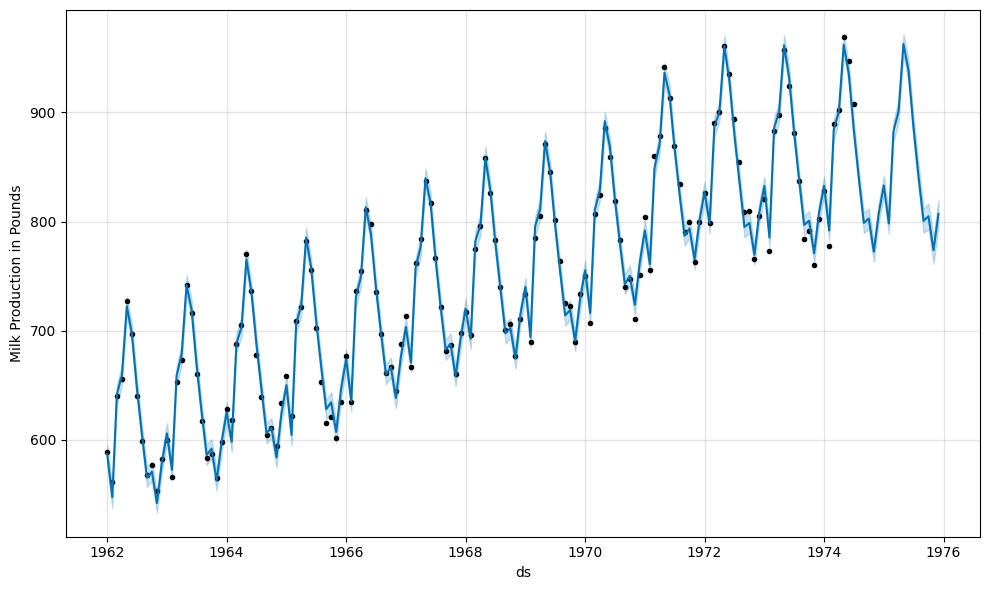

In [25]:
model.plot(forecast, ylabel='Milk Production in Pounds'); plt.show()